In [1]:
# ── Install all required libraries (run this cell first) ──────────────────────
!pip install seaborn imbalanced-learn scikit-learn matplotlib pandas numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ------------- -------------------------- 1/3 [seaborn]
   ------------- -------------------------- 1/3 [seaborn]
   ------------- -------------------------- 1/3 [seaborn]
   -------------------------- ------------- 2/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imbalanced-learn]



# 🦟 Feature Engineering — Climate Change & Malaria Outbreak Prediction
### MLOps Project | Likhita Kolli & Naa Lamiorkor Boye

---

## 📋 Notebook Overview

This notebook covers **every feature engineering step** required to turn the raw `malaria_final_dataset.csv` into a production-ready ML training set.

| Step | What We Do | Why It Matters |
|------|-----------|----------------|
| 1 | Load & inspect data | Understand shape, nulls, distributions |
| 2 | Create outbreak label (target) | Define what we're predicting |
| 3 | Lag features | Give model access to historical context |
| 4 | Rolling averages | Smooth noise, capture trends |
| 5 | Climate interaction features | Model non-linear climate effects |
| 6 | Socioeconomic features | Capture vulnerability context |
| 7 | Normalization / scaling | Prepare features for ML algorithms |
| 8 | Train / val / test split | Respect temporal ordering |
| 9 | Export final dataset | Save for model training |

> **Dataset:** 2,402 rows × 9 columns | 106 countries | 2000–2022


---
## Step 0 — Install & Import Libraries

### 📚 Libraries Used

| Library | Version | Purpose | Docs |
|---------|---------|---------|------|
| `pandas` | ≥1.5 | Data manipulation, groupby, shift, rolling | https://pandas.pydata.org/docs/ |
| `numpy` | ≥1.23 | Numerical operations, log transforms | https://numpy.org/doc/ |
| `scikit-learn` | ≥1.2 | Scaling, train/test split, preprocessing | https://scikit-learn.org/stable/ |
| `matplotlib` | ≥3.6 | Plotting distributions & correlations | https://matplotlib.org/stable/ |
| `seaborn` | ≥0.12 | Statistical visualizations | https://seaborn.pydata.org/ |
| `imbalanced-learn` | ≥0.10 | SMOTE for class imbalance | https://imbalanced-learn.org/stable/ |


In [ ]:
# ── Standard library installs (run once if needed) ──────────────────────────
# !pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

print("✅ All libraries imported successfully")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")


✅ All libraries imported successfully
   pandas  : 2.3.3
   numpy   : 2.2.6


---
## Step 1 — Load & Inspect the Dataset

### Why this matters
Before engineering anything, you need to understand:
- The **shape** of the data (rows, columns)
- The **data types** of each column
- Whether there are **missing values**
- The **distribution** of the target variable (Malaria_Incidence)

### Key Pandas methods used

| Method | What it does | Docs |
|--------|-------------|------|
| `pd.read_csv()` | Load CSV into DataFrame | [link](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) |
| `df.info()` | Show dtypes, nulls, memory | [link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) |
| `df.describe()` | Summary statistics per column | [link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) |
| `df.isnull().sum()` | Count missing values per column | [link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html) |
| `df.nunique()` | Count unique values per column | [link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html) |


In [ ]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# Update path if running locally
df = pd.read_csv(r'C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\Data\Processed\malaria_final_dataset.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape         : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Countries     : {df['Country Name'].nunique()}")
print(f"Year range    : {df['Year'].min()} – {df['Year'].max()}")
print(f"Missing values: {df.isnull().sum().sum()} total")
print()
df.info()


DATASET OVERVIEW
Shape         : 2402 rows × 9 columns
Countries     : 106
Year range    : 2000 – 2022
Missing values: 0 total

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2402 entries, 0 to 2401
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country Name               2402 non-null   object 
 1   Country Code               2402 non-null   object 
 2   Year                       2402 non-null   int64  
 3   Malaria_Incidence          2402 non-null   float64
 4   Precipitation_mm           2402 non-null   float64
 5   Pop_Density                2402 non-null   float64
 6   GDP_per_Capita             2402 non-null   float64
 7   Temp_Annual_Mean_C         2402 non-null   float64
 8   Temp_GrowingSeason_Mean_C  2402 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 169.0+ KB


In [ ]:
# ── Statistical summary ──────────────────────────────────────────────────────
df.describe().round(2)


,Year,Malaria_Incidence,Precipitation_mm,Pop_Density,GDP_per_Capita,Temp_Annual_Mean_C,Temp_GrowingSeason_Mean_C
count,2402.00,2402.00,2402.00,2402.00,2402.00,2402.00,2402.00
mean,2010.99,105.65,1249.01,103.36,3716.22,23.46,23.49
std,6.61,151.32,854.74,150.98,5196.04,5.50,5.51
min,2000.00,0.00,18.10,2.21,233.03,3.13,2.58
25%,2005.00,0.37,495.00,21.28,933.96,21.84,21.92
50%,2011.00,10.30,1150.00,56.53,2013.58,25.33,25.32
75%,2017.00,208.47,1821.00,114.68,4421.45,27.09,27.15
max,2022.00,718.98,3240.00,1300.36,45168.50,30.39,30.20


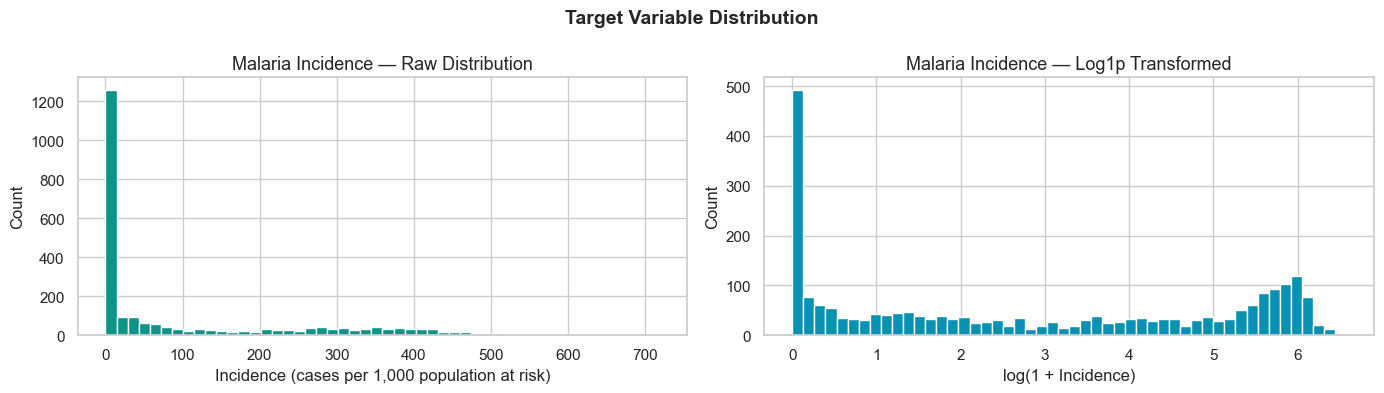

Zero incidence rows : 339
Max incidence       : 718.98
Median incidence    : 10.29


In [ ]:
# ── Distribution of the target: Malaria Incidence ────────────────────────────
# IMPORTANT: The target is HIGHLY skewed (many low-incidence countries, 
# a few very high ones). This is typical of disease surveillance data.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
axes[0].hist(df['Malaria_Incidence'], bins=50, color='#0D9488', edgecolor='white')
axes[0].set_title('Malaria Incidence — Raw Distribution')
axes[0].set_xlabel('Incidence (cases per 1,000 population at risk)')
axes[0].set_ylabel('Count')

# Log-transformed — reveals the full shape
axes[1].hist(np.log1p(df['Malaria_Incidence']), bins=50, color='#0891B2', edgecolor='white')
axes[1].set_title('Malaria Incidence — Log1p Transformed')
axes[1].set_xlabel('log(1 + Incidence)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Zero incidence rows : {(df['Malaria_Incidence'] == 0).sum()}")
print(f"Max incidence       : {df['Malaria_Incidence'].max()}")
print(f"Median incidence    : {df['Malaria_Incidence'].median():.2f}")


---
## Step 2 — Sort & Set Up Temporal Structure

### Why this matters
Our data is a **time series** — each row is a country-year pair. Every feature 
we create (lags, rolling averages) depends on rows being in the correct 
**chronological order within each country**.

If we skip this step and the data is not sorted, lag features will 
accidentally pull values from the *wrong year*, causing **silent data leakage**.

### Key Pandas methods

| Method | What it does | Docs |
|--------|-------------|------|
| `df.sort_values()` | Sort rows by column(s) | [link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html) |
| `df.reset_index()` | Reset integer index after sort | [link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html) |
| `df.groupby()` | Group rows by country for per-country operations | [link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) |


In [ ]:
# ── Sort by Country then Year (CRITICAL for lag features) ────────────────────
df = df.sort_values(['Country Name', 'Year']).reset_index(drop=True)

print("✅ Data sorted by Country → Year")
print()

# Verify: show Afghanistan's rows in order
sample = df[df['Country Name'] == 'Afghanistan'][['Country Name', 'Year', 'Malaria_Incidence']].head(8)
print("Sample — Afghanistan time series:")
print(sample.to_string(index=False))
print()
print(f"Total countries : {df['Country Name'].nunique()}")
print(f"Years covered   : {df['Year'].min()} – {df['Year'].max()}")


✅ Data sorted by Country → Year

Sample — Afghanistan time series:
Country Name  Year  Malaria_Incidence
 Afghanistan  2000              84.48
 Afghanistan  2001              83.83
 Afghanistan  2002              83.79
 Afghanistan  2003              70.81
 Afghanistan  2004              39.41
 Afghanistan  2005              28.42
 Afghanistan  2006              21.31
 Afghanistan  2007              22.63

Total countries : 106
Years covered   : 2000 – 2022


---
## Step 3 — Create the Outbreak Label (Target Variable)

### Why this matters
Our ML goal is **binary classification**: predict whether a country will 
experience an outbreak *next year*.

We need to:
1. Define what counts as an "outbreak" (threshold on Malaria_Incidence)
2. **Shift the label forward by 1 year** so the model learns: 
   *"given this year's data, will next year have an outbreak?"*

### Threshold choice
We use the **75th percentile** of Malaria_Incidence as the outbreak threshold.
- Countries above this level are in the top quartile of severity
- This is a principled, data-driven threshold (not arbitrary)
- You can adjust this threshold to change sensitivity vs specificity

### Key Pandas method: `.shift()`

`GroupBy.shift(n)` shifts values **within each group** by n positions.  
Using `shift(-1)` pulls the *next* row's value into the current row.

```python
# Conceptually:
# Year 2000 → gets label from Year 2001
# Year 2001 → gets label from Year 2002
# Year 2002 → gets label from Year 2003
# ...
# Year 2022 → NaN (no next year exists)
```

📖 **Docs:** https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.shift.html


In [ ]:
# ── Define outbreak threshold ─────────────────────────────────────────────────
OUTBREAK_THRESHOLD = df['Malaria_Incidence'].quantile(0.75)
print(f"Outbreak threshold (75th percentile): {OUTBREAK_THRESHOLD:.2f} cases per 1,000")

# ── Create next-year incidence (shifted within each country group) ────────────
# groupby ensures shift stays within each country's timeline
df['Next_Year_Incidence'] = (
    df.groupby('Country Name')['Malaria_Incidence']
    .shift(-1)   # -1 means "look 1 step into the future"
)

# ── Binary outbreak label ─────────────────────────────────────────────────────
# 1 = outbreak next year, 0 = no outbreak next year
df['Outbreak_Label'] = (df['Next_Year_Incidence'] >= OUTBREAK_THRESHOLD).astype(int)

# ── Also create outbreak probability proxy (for soft targets / inspection) ────
df['Outbreak_Probability'] = (df['Next_Year_Incidence'] / df['Malaria_Incidence'].max()).clip(0, 1)

print()
print("Label distribution:")
label_counts = df['Outbreak_Label'].value_counts()
print(f"  No outbreak (0) : {label_counts[0]:,}  ({label_counts[0]/len(df)*100:.1f}%)")
print(f"  Outbreak    (1) : {label_counts[1]:,}  ({label_counts[1]/len(df)*100:.1f}%)")
print()
print("⚠️  Class imbalance noted — we will handle this with SMOTE in Step 8")


Outbreak threshold (75th percentile): 208.47 cases per 1,000

Label distribution:
  No outbreak (0) : 1,834  (76.4%)
  Outbreak    (1) : 568  (23.6%)

⚠️  Class imbalance noted — we will handle this with SMOTE in Step 8


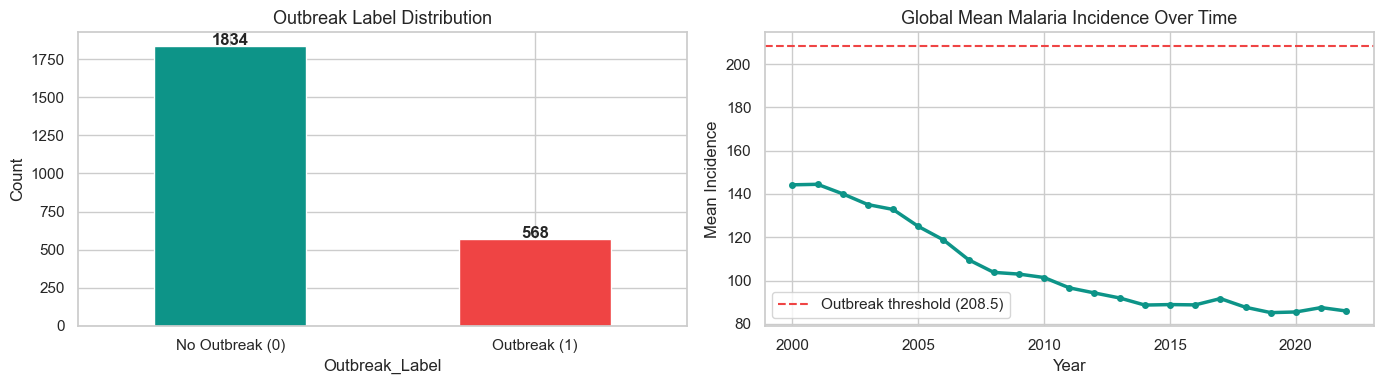

In [ ]:
# ── Visualise label distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
label_counts.plot(kind='bar', ax=axes[0], color=['#0D9488', '#EF4444'], edgecolor='white')
axes[0].set_title('Outbreak Label Distribution')
axes[0].set_xticklabels(['No Outbreak (0)', 'Outbreak (1)'], rotation=0)
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Incidence over time (global mean)
yearly_mean = df.groupby('Year')['Malaria_Incidence'].mean()
axes[1].plot(yearly_mean.index, yearly_mean.values, color='#0D9488', linewidth=2.5, marker='o', markersize=4)
axes[1].axhline(OUTBREAK_THRESHOLD, color='#EF4444', linestyle='--', label=f'Outbreak threshold ({OUTBREAK_THRESHOLD:.1f})')
axes[1].set_title('Global Mean Malaria Incidence Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Incidence')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## Step 4 — Lag Features

### Why this matters
Malaria outbreaks are **not random events** — they have memory.  
A country that had high incidence last year is more likely to have high 
incidence this year. Lag features give the model access to this **historical context**.

Without lag features, the model can only see a single snapshot in time.  
With them, it learns: *"this country has been trending upward for 3 years"*.

### What we create

| Feature | Formula | Meaning |
|---------|---------|---------|
| `Malaria_Lag1` | incidence at t-1 | Last year's incidence |
| `Malaria_Lag2` | incidence at t-2 | Two years ago |
| `Malaria_Lag3` | incidence at t-3 | Three years ago |
| `Temp_Lag1` | temperature at t-1 | Last year's temperature |
| `Precip_Lag1` | precipitation at t-1 | Last year's rainfall |

### Key method: `GroupBy.shift(n)` with positive n

`shift(1)` pulls the **previous** row's value into the current row (past data).  
`shift(-1)` pulls the **next** row's value (future — used for labels only).

📖 **Docs:** https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.shift.html

```
Country | Year | Malaria_Incidence | Malaria_Lag1 | Malaria_Lag2
Angola  | 2000 |       300         |     NaN      |     NaN
Angola  | 2001 |       320         |     300      |     NaN
Angola  | 2002 |       280         |     320      |     300
```


In [ ]:
# ── Lag features (shift WITHIN each country group) ───────────────────────────
# Using groupby('Country Name') ensures Angola's 2001 lag 
# comes from Angola 2000, NOT from the last row of a different country.

grp = df.groupby('Country Name')

# Malaria incidence lags (1, 2, 3 years back)
df['Malaria_Lag1'] = grp['Malaria_Incidence'].shift(1)
df['Malaria_Lag2'] = grp['Malaria_Incidence'].shift(2)
df['Malaria_Lag3'] = grp['Malaria_Incidence'].shift(3)

# Climate lags (1 year back — temperature and precipitation)
df['Temp_Lag1']   = grp['Temp_Annual_Mean_C'].shift(1)
df['Precip_Lag1'] = grp['Precipitation_mm'].shift(1)
df['GDP_Lag1']    = grp['GDP_per_Capita'].shift(1)

print("✅ Lag features created:")
lag_cols = [c for c in df.columns if 'Lag' in c]
for col in lag_cols:
    nulls = df[col].isnull().sum()
    print(f"   {col:25s} → {nulls} NaN rows (expected — first years have no history)")

print()
# Show an example for Angola
print("Example — Angola lag features:")
angola = df[df['Country Name'] == 'Angola'][
    ['Year', 'Malaria_Incidence', 'Malaria_Lag1', 'Malaria_Lag2', 'Malaria_Lag3']
].head(6)
print(angola.to_string(index=False))


✅ Lag features created:
   Malaria_Lag1              → 106 NaN rows (expected — first years have no history)
   Malaria_Lag2              → 212 NaN rows (expected — first years have no history)
   Malaria_Lag3              → 318 NaN rows (expected — first years have no history)
   Temp_Lag1                 → 106 NaN rows (expected — first years have no history)
   Precip_Lag1               → 106 NaN rows (expected — first years have no history)
   GDP_Lag1                  → 106 NaN rows (expected — first years have no history)

Example — Angola lag features:
 Year  Malaria_Incidence  Malaria_Lag1  Malaria_Lag2  Malaria_Lag3
 2000             326.54           NaN           NaN           NaN
 2001             330.80        326.54           NaN           NaN
 2002             315.70        330.80        326.54           NaN
 2003             319.29        315.70        330.80        326.54
 2004             312.65        319.29        315.70        330.80
 2005             313.87        

---
## Step 5 — Rolling Average Features

### Why this matters
Single-year values are **noisy** — a drought one year, unusual rainfall another.  
Rolling averages **smooth out noise** and capture sustained trends.

A 3-year rolling mean of temperature tells the model: *"this region has been 
consistently getting warmer"* — which is more predictive than a single year's spike.

### What we create

| Feature | Window | Meaning |
|---------|--------|---------|
| `Malaria_Roll3` | 3 years | Sustained incidence trend |
| `Temp_Roll3` | 3 years | Multi-year temperature trend |
| `Precip_Roll3` | 3 years | Multi-year rainfall trend |
| `Malaria_YoY_Change` | 2 years | Year-over-year change rate |

### Key method: `GroupBy.rolling()`

```python
df.groupby('Country Name')['col'].transform(
    lambda x: x.rolling(window=3, min_periods=2).mean()
)
```

- `window=3` → use last 3 values
- `min_periods=2` → compute even if only 2 values available (avoids extra NaNs)
- `.transform()` → keeps the same index as the original DataFrame

📖 **Rolling docs:** https://pandas.pydata.org/docs/reference/api/pandas.core.window.rolling.Rolling.mean.html  
📖 **Transform docs:** https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.transform.html


✅ Rolling features created:
   Malaria_Roll3             → 106 NaN rows
   Temp_Roll3                → 106 NaN rows
   Precip_Roll3              → 106 NaN rows
   Malaria_YoY_Change        → 416 NaN rows



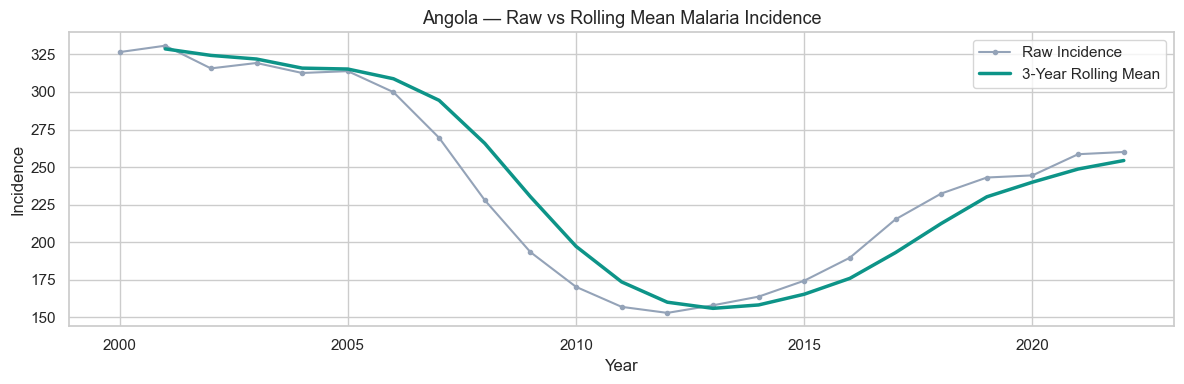

In [ ]:
# ── Rolling average features ─────────────────────────────────────────────────
# We use transform() to apply rolling within groups and keep the same DataFrame index

def rolling_mean(series, window=3, min_periods=2):
    """Compute rolling mean within a group, keeping index aligned."""
    return series.rolling(window=window, min_periods=min_periods).mean()

# 3-year rolling means
df['Malaria_Roll3'] = (
    df.groupby('Country Name')['Malaria_Incidence']
    .transform(lambda x: rolling_mean(x, window=3))
)

df['Temp_Roll3'] = (
    df.groupby('Country Name')['Temp_Annual_Mean_C']
    .transform(lambda x: rolling_mean(x, window=3))
)

df['Precip_Roll3'] = (
    df.groupby('Country Name')['Precipitation_mm']
    .transform(lambda x: rolling_mean(x, window=3))
)

# ── Year-over-year change in malaria incidence ────────────────────────────────
# Captures acceleration/deceleration of outbreak trajectory
# pct_change() = (current - previous) / previous
df['Malaria_YoY_Change'] = (
    df.groupby('Country Name')['Malaria_Incidence']
    .transform(lambda x: x.pct_change())
)

# Cap extreme pct_change values (e.g., going from 0 → any value gives inf)
df['Malaria_YoY_Change'] = df['Malaria_YoY_Change'].replace([np.inf, -np.inf], np.nan)
df['Malaria_YoY_Change'] = df['Malaria_YoY_Change'].clip(-5, 5)  # cap at ±500%

print("✅ Rolling features created:")
roll_cols = ['Malaria_Roll3', 'Temp_Roll3', 'Precip_Roll3', 'Malaria_YoY_Change']
for col in roll_cols:
    print(f"   {col:25s} → {df[col].isnull().sum()} NaN rows")

print()
# Visual: raw vs rolling for a sample country
country = 'Angola'
sub = df[df['Country Name'] == country]

plt.figure(figsize=(12, 4))
plt.plot(sub['Year'], sub['Malaria_Incidence'], label='Raw Incidence', color='#94A3B8', linewidth=1.5, marker='o', markersize=3)
plt.plot(sub['Year'], sub['Malaria_Roll3'],     label='3-Year Rolling Mean', color='#0D9488', linewidth=2.5)
plt.title(f'{country} — Raw vs Rolling Mean Malaria Incidence')
plt.xlabel('Year')
plt.ylabel('Incidence')
plt.legend()
plt.tight_layout()
plt.show()


---
## Step 6 — Climate Interaction Features

### Why this matters
The relationship between climate and malaria is **non-linear and interactive**.  
Temperature and rainfall don't act independently — *warm + wet* conditions are 
far more dangerous than either alone (optimal mosquito breeding requires both).

XGBoost *can* learn interactions automatically, but explicitly encoding them:
- **Speeds up learning** (model doesn't need to discover them)
- **Improves interpretability** (you can explain each feature)
- **Helps with smaller datasets** like ours (106 countries × 23 years)

### Features we create

| Feature | Formula | Scientific basis |
|---------|---------|-----------------|
| `Temp_Precip_Interaction` | Temp × Precip | Hot + wet = peak mosquito breeding |
| `Temp_Squared` | Temp² | Non-linear threshold effect on parasite development |
| `Climate_Risk_Index` | (Temp × Precip) / (GDP + 1) | Risk adjusted for economic capacity |
| `Vulnerability_Index` | Pop_Density / (GDP + 1) | Population exposure relative to resources |


In [ ]:
# ── Climate interaction features ──────────────────────────────────────────────

# 1. Temperature × Precipitation interaction
#    Scientific basis: Anopheles mosquito breeding requires warm AND wet conditions
#    (Mordecai et al., 2013 — optimal temp ~25°C + rainfall for breeding pools)
df['Temp_Precip_Interaction'] = df['Temp_Annual_Mean_C'] * df['Precipitation_mm']

# 2. Temperature squared
#    Captures the non-linear "thermal performance curve" of malaria parasites
#    (too cold = no transmission, optimal ~25°C, too hot = reduced survival)
df['Temp_Squared'] = df['Temp_Annual_Mean_C'] ** 2

# 3. Climate Risk Index
#    Combines climate threat with socioeconomic vulnerability
#    Countries with same climate risk but lower GDP are more exposed
df['Climate_Risk_Index'] = (df['Temp_Annual_Mean_C'] * df['Precipitation_mm']) / (df['GDP_per_Capita'] + 1)

# 4. Vulnerability Index
#    High population density + low GDP = high transmission + poor healthcare
df['Vulnerability_Index'] = df['Pop_Density'] / (df['GDP_per_Capita'] + 1)

# 5. Log GDP (reduces skew, common in econometric models)
df['Log_GDP'] = np.log1p(df['GDP_per_Capita'])

# 6. Log Malaria Incidence (for use as a feature, not label)
df['Log_Malaria_Incidence'] = np.log1p(df['Malaria_Incidence'])

print("✅ Interaction features created:")
interaction_cols = ['Temp_Precip_Interaction', 'Temp_Squared', 'Climate_Risk_Index', 
                    'Vulnerability_Index', 'Log_GDP', 'Log_Malaria_Incidence']
for col in interaction_cols:
    print(f"   {col:30s} → mean={df[col].mean():.4f}, std={df[col].std():.4f}")

print()
print("Correlation of new features with Outbreak_Label:")
corr = df[interaction_cols + ['Outbreak_Label']].corr()['Outbreak_Label'].drop('Outbreak_Label')
print(corr.sort_values(ascending=False).round(3).to_string())


✅ Interaction features created:
   Temp_Precip_Interaction        → mean=30553.1425, std=23333.9210
   Temp_Squared                   → mean=580.7834, std=210.7456
   Climate_Risk_Index             → mean=21.9080, std=25.3107
   Vulnerability_Index            → mean=0.0887, std=0.2051
   Log_GDP                        → mean=7.6423, std=1.0462
   Log_Malaria_Incidence          → mean=2.7920, std=2.3145

Correlation of new features with Outbreak_Label:
Log_Malaria_Incidence      0.730
Climate_Risk_Index         0.427
Temp_Squared               0.252
Vulnerability_Index        0.125
Temp_Precip_Interaction    0.072
Log_GDP                   -0.425


---
## Step 7 — Define Final Feature Set & Handle NaNs

### Why NaNs appear
Lag and rolling features always produce NaN for the **first N rows** of each 
country (e.g., Lag1 for the year 2000 has no 1999 to look back to).

We also have NaN in `Outbreak_Label` for each country's **last year** 
(2022 has no 2023 to shift into).

### Strategy
We **drop these NaN rows** — they contain no usable label or features.  
This is correct because:
- We cannot train on rows with unknown labels
- We cannot use rows where features are undefined
- Imputing lags would introduce false data leakage

After dropping, we verify the class balance and final dataset size.


In [ ]:
# ── Define the complete feature set ──────────────────────────────────────────
FEATURE_COLS = [
    # Original features
    'Malaria_Incidence',
    'Precipitation_mm',
    'Pop_Density',
    'GDP_per_Capita',
    'Temp_Annual_Mean_C',
    'Temp_GrowingSeason_Mean_C',
    
    # Lag features
    'Malaria_Lag1',
    'Malaria_Lag2',
    'Malaria_Lag3',
    'Temp_Lag1',
    'Precip_Lag1',
    'GDP_Lag1',
    
    # Rolling averages
    'Malaria_Roll3',
    'Temp_Roll3',
    'Precip_Roll3',
    'Malaria_YoY_Change',
    
    # Interaction / engineered
    'Temp_Precip_Interaction',
    'Temp_Squared',
    'Climate_Risk_Index',
    'Vulnerability_Index',
    'Log_GDP',
    'Log_Malaria_Incidence',
]

TARGET_COL = 'Outbreak_Label'

print(f"Total features defined: {len(FEATURE_COLS)}")
print()

# ── Drop rows where label or any feature is NaN ───────────────────────────────
df_model = df[FEATURE_COLS + [TARGET_COL, 'Country Name', 'Year']].copy()

before = len(df_model)
df_model = df_model.dropna()
after = len(df_model)

print(f"Rows before dropping NaN : {before:,}")
print(f"Rows after  dropping NaN : {after:,}")
print(f"Rows dropped             : {before - after:,} (first/last years per country)")
print()

# Final class balance
label_counts = df_model[TARGET_COL].value_counts()
print("Final label distribution:")
print(f"  No outbreak (0) : {label_counts[0]:,}  ({label_counts[0]/len(df_model)*100:.1f}%)")
print(f"  Outbreak    (1) : {label_counts[1]:,}  ({label_counts[1]/len(df_model)*100:.1f}%)")


Total features defined: 22

Rows before dropping NaN : 2,402
Rows after  dropping NaN : 1,789
Rows dropped             : 613 (first/last years per country)

Final label distribution:
  No outbreak (0) : 1,320  (73.8%)
  Outbreak    (1) : 469  (26.2%)


---
## Step 8 — Correlation & Feature Relevance Analysis

### Why this matters
Before scaling or training, it's good practice to:
1. Check which features are **most correlated with the target** (feature relevance)
2. Identify **highly correlated feature pairs** (multicollinearity)
3. Drop or merge features that are near-duplicate (reduces overfitting)

### Key tool: `df.corr()`
📖 **Docs:** https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html


Feature correlations with Outbreak_Label (sorted):
Malaria_Incidence            0.888
Malaria_Roll3                0.881
Malaria_Lag1                 0.878
Malaria_Lag2                 0.866
Malaria_Lag3                 0.852
Log_Malaria_Incidence        0.717
Climate_Risk_Index           0.391
Temp_Squared                 0.218
Temp_Annual_Mean_C           0.216
Temp_Roll3                   0.216
Temp_Lag1                    0.216
Temp_GrowingSeason_Mean_C    0.213
Vulnerability_Index          0.121
Malaria_YoY_Change           0.011
Temp_Precip_Interaction     -0.022
Precip_Lag1                 -0.059
Precipitation_mm            -0.059
Precip_Roll3                -0.059
Pop_Density                 -0.088
GDP_Lag1                    -0.259
GDP_per_Capita              -0.261
Log_GDP                     -0.412



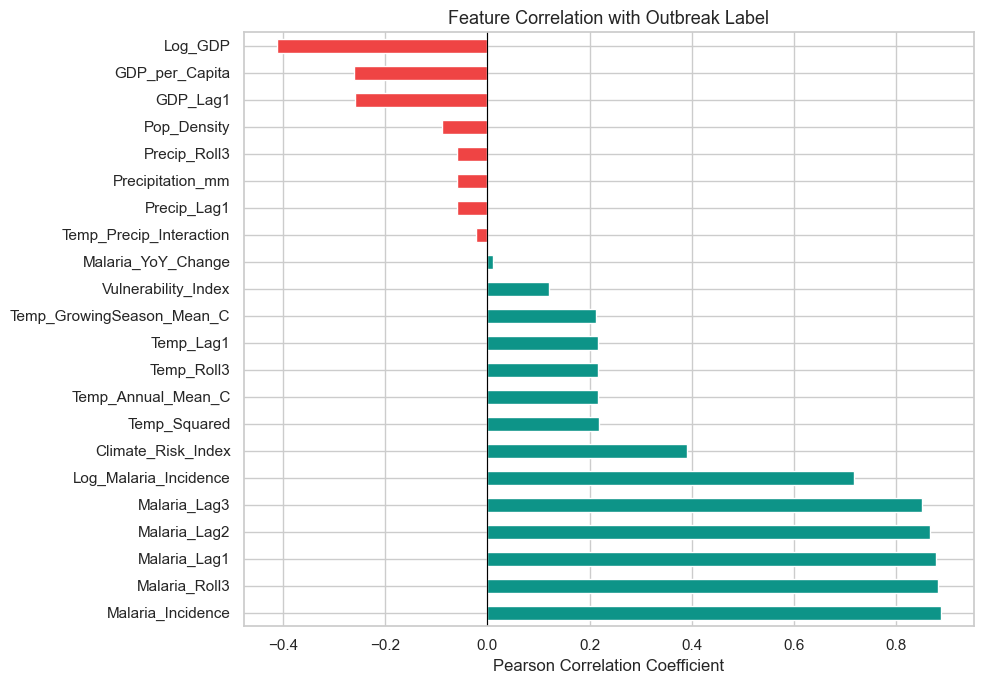

In [ ]:
# ── Correlation with target ───────────────────────────────────────────────────
corr_with_target = (
    df_model[FEATURE_COLS + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(ascending=False)
)

print("Feature correlations with Outbreak_Label (sorted):")
print(corr_with_target.round(3).to_string())
print()

# Plot
plt.figure(figsize=(10, 7))
colors = ['#0D9488' if v > 0 else '#EF4444' for v in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Outbreak Label')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()


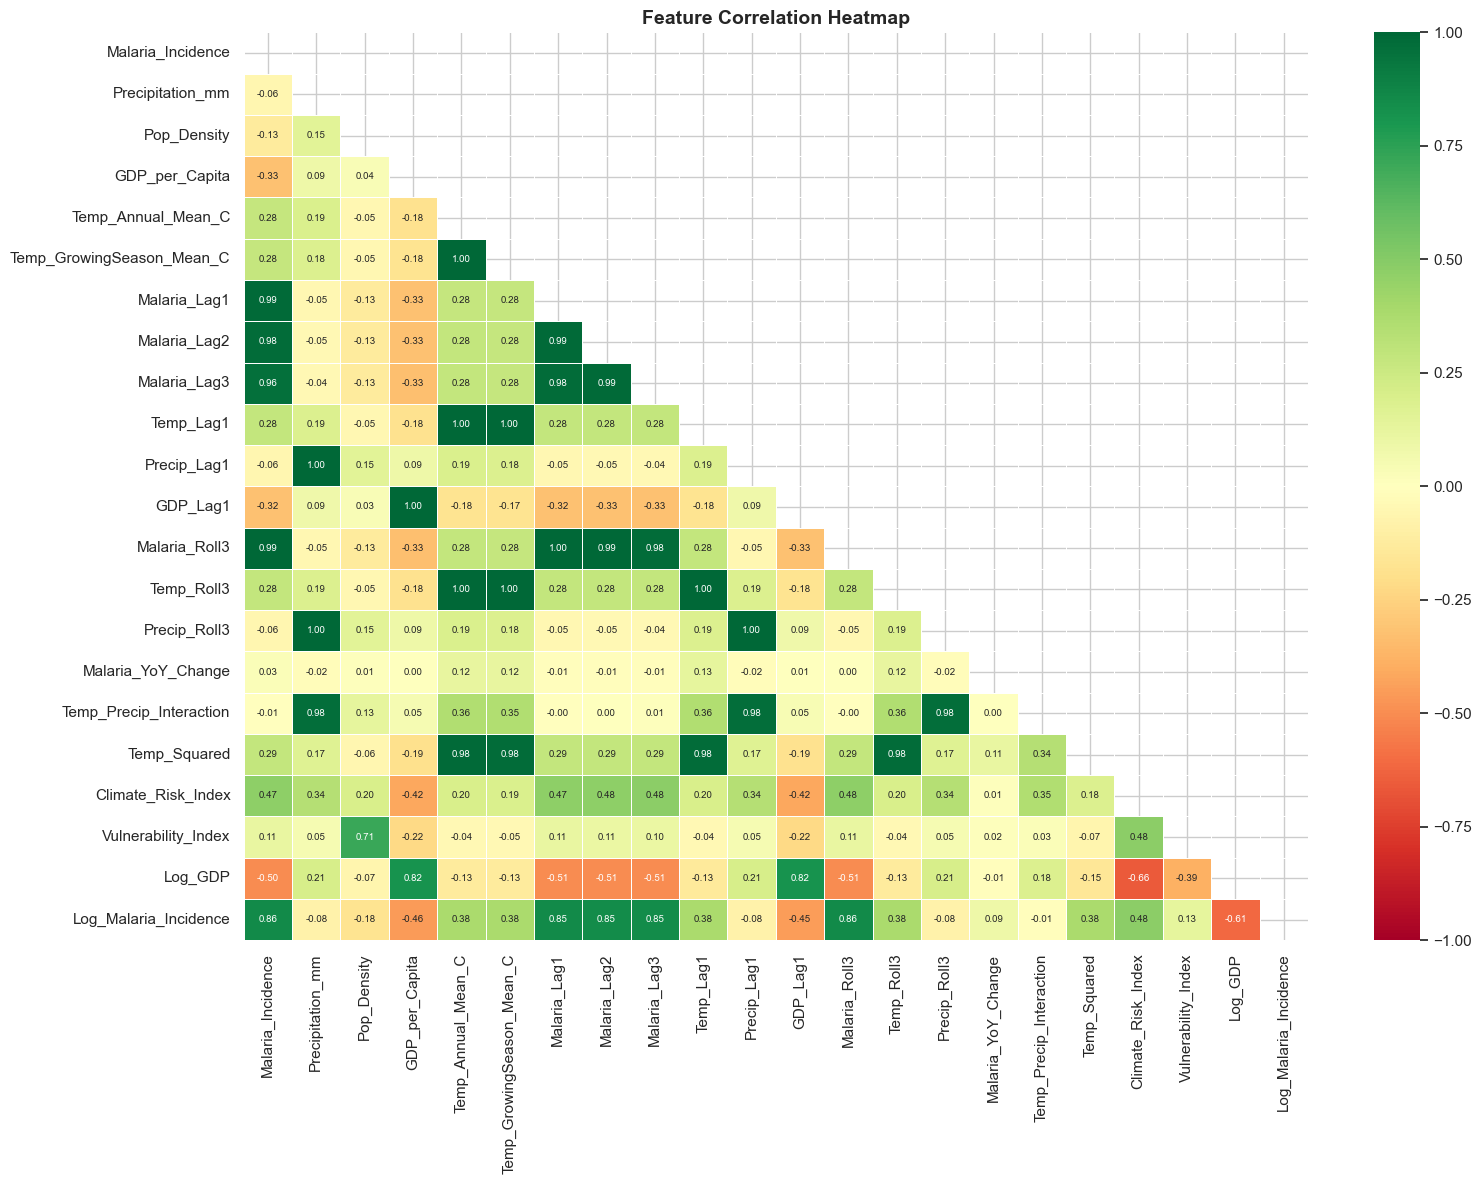

Highly correlated feature pairs (|r| > 0.90):
  Malaria_Incidence ↔ Malaria_Lag1 : r=0.99
  Malaria_Incidence ↔ Malaria_Lag2 : r=0.977
  Malaria_Incidence ↔ Malaria_Lag3 : r=0.962
  Malaria_Incidence ↔ Malaria_Roll3 : r=0.993
  Precipitation_mm ↔ Precip_Lag1 : r=1.0
  Precipitation_mm ↔ Precip_Roll3 : r=1.0
  Precipitation_mm ↔ Temp_Precip_Interaction : r=0.976
  GDP_per_Capita ↔ GDP_Lag1 : r=0.998
  Temp_Annual_Mean_C ↔ Temp_GrowingSeason_Mean_C : r=0.999
  Temp_Annual_Mean_C ↔ Temp_Lag1 : r=0.997
  Temp_Annual_Mean_C ↔ Temp_Roll3 : r=0.999
  Temp_Annual_Mean_C ↔ Temp_Squared : r=0.985
  Temp_GrowingSeason_Mean_C ↔ Temp_Lag1 : r=0.997
  Temp_GrowingSeason_Mean_C ↔ Temp_Roll3 : r=0.998
  Temp_GrowingSeason_Mean_C ↔ Temp_Squared : r=0.983
  Malaria_Lag1 ↔ Malaria_Lag2 : r=0.99
  Malaria_Lag1 ↔ Malaria_Lag3 : r=0.977
  Malaria_Lag1 ↔ Malaria_Roll3 : r=0.998
  Malaria_Lag2 ↔ Malaria_Lag3 : r=0.99
  Malaria_Lag2 ↔ Malaria_Roll3 : r=0.994
  Malaria_Lag3 ↔ Malaria_Roll3 : r=0.981
  Temp_Lag1

In [ ]:
# ── Heatmap of feature correlations ──────────────────────────────────────────
# Identify highly correlated feature pairs (|corr| > 0.90 → potential redundancy)

corr_matrix = df_model[FEATURE_COLS].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
print("Highly correlated feature pairs (|r| > 0.90):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.90:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

if high_corr:
    for a, b, r in high_corr:
        print(f"  {a} ↔ {b} : r={r}")
else:
    print("  None found above 0.90 threshold ✅")


---
## Step 9 — Feature Scaling

### Why this matters

| Model | Needs Scaling? | Reason |
|-------|---------------|--------|
| Logistic Regression | ✅ YES | Sensitive to feature magnitude — large features dominate gradient |
| XGBoost | ❌ No | Tree-based splits are scale-invariant |
| SVM | ✅ YES | Distance-based — must scale |
| Neural Net | ✅ YES | Gradient descent unstable with unscaled features |

Since you're using **both Logistic Regression AND XGBoost**, we'll create 
two versions of the feature matrix: scaled (for LogReg) and unscaled (for XGBoost).

### StandardScaler vs MinMaxScaler

| Scaler | Formula | When to use |
|--------|---------|-------------|
| `StandardScaler` | (x - mean) / std | When features roughly follow normal distribution |
| `MinMaxScaler` | (x - min) / (max - min) | When you need bounded [0,1] range |

We use **StandardScaler** as primary — our features have varying scales 
(GDP in thousands, temperature in degrees, incidence in hundreds).

### ⚠️ Critical Rule: Fit on TRAIN only, transform on ALL

```python
scaler.fit(X_train)       # ✅ Learn parameters from train only
scaler.transform(X_train) # ✅ Apply to train
scaler.transform(X_val)   # ✅ Apply same parameters to val
scaler.transform(X_test)  # ✅ Apply same parameters to test
```

Never `scaler.fit(X_test)` — that leaks test statistics into your pipeline.

📖 **StandardScaler docs:** https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html


---
## Step 10 — Temporal Train / Validation / Test Split

### Why NOT to use random split
This is a **time-series problem**. Using `train_test_split(shuffle=True)` would:
- Let the model train on 2020 data and test on 2005 data
- This is **data leakage** — the model would be using future knowledge
- Test accuracy would be falsely high and useless in production

### Correct approach: split by year

```
2000–2016  →  Training set   (17 years, ~74% of data)
2017–2019  →  Validation set (3 years, hyperparameter tuning)
2020–2022  →  Test set       (3 years, final evaluation only)
```

This mirrors real deployment: train on the past, validate on recent history, 
test on the most recent years.

📖 **Docs:** https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html


TEMPORAL SPLIT SUMMARY
Train  (2000–2016): 1300 rows  |  outbreak rate: 26.7%
Val    (2017–2019):   252 rows  |  outbreak rate: 29.8%
Test   (2020–2022):   237 rows  |  outbreak rate: 19.8%
Total            : 1789 rows



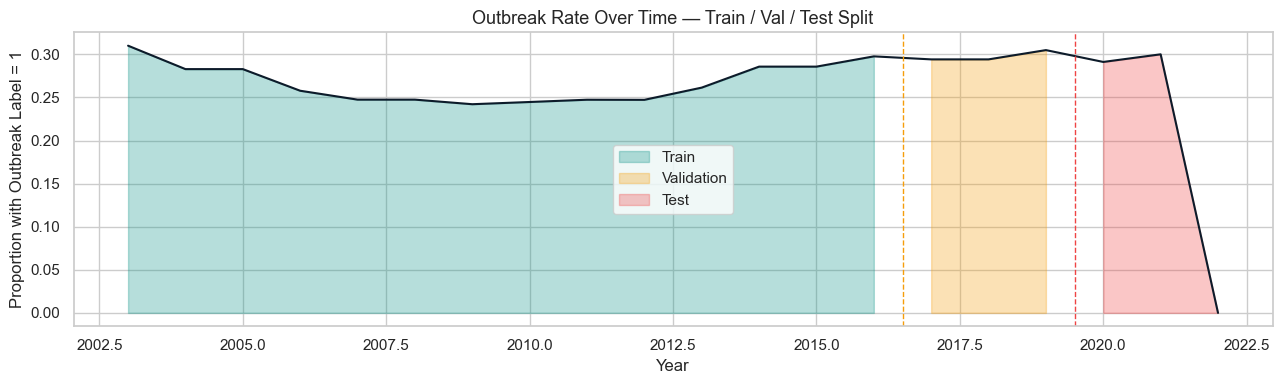

In [ ]:
# ── Temporal split boundaries ─────────────────────────────────────────────────
TRAIN_END  = 2016
VAL_END    = 2019
# Test = 2020–2022

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]
years = df_model['Year']

# ── Split masks ───────────────────────────────────────────────────────────────
train_mask = years <= TRAIN_END
val_mask   = (years > TRAIN_END) & (years <= VAL_END)
test_mask  = years > VAL_END

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("=" * 50)
print("TEMPORAL SPLIT SUMMARY")
print("=" * 50)
print(f"Train  (2000–{TRAIN_END}): {len(X_train):>4} rows  |  outbreak rate: {y_train.mean():.1%}")
print(f"Val    ({TRAIN_END+1}–{VAL_END}):  {len(X_val):>4} rows  |  outbreak rate: {y_val.mean():.1%}")
print(f"Test   ({VAL_END+1}–2022):  {len(X_test):>4} rows  |  outbreak rate: {y_test.mean():.1%}")
print(f"Total            : {len(X):>4} rows")
print()

# ── Visualise the split ───────────────────────────────────────────────────────
yearly_counts = df_model.groupby('Year')[TARGET_COL].mean()

plt.figure(figsize=(13, 4))
train_years = yearly_counts[yearly_counts.index <= TRAIN_END]
val_years   = yearly_counts[(yearly_counts.index > TRAIN_END) & (yearly_counts.index <= VAL_END)]
test_years  = yearly_counts[yearly_counts.index > VAL_END]

plt.fill_between(train_years.index, train_years.values, alpha=0.3, color='#0D9488', label='Train')
plt.fill_between(val_years.index,   val_years.values,   alpha=0.3, color='#F59E0B', label='Validation')
plt.fill_between(test_years.index,  test_years.values,  alpha=0.3, color='#EF4444', label='Test')

plt.plot(yearly_counts.index, yearly_counts.values, color='#0D1B2A', linewidth=1.5)
plt.axvline(TRAIN_END + 0.5, color='#F59E0B', linestyle='--', linewidth=1)
plt.axvline(VAL_END + 0.5,   color='#EF4444', linestyle='--', linewidth=1)

plt.title('Outbreak Rate Over Time — Train / Val / Test Split')
plt.xlabel('Year')
plt.ylabel('Proportion with Outbreak Label = 1')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── StandardScaler — fit on train ONLY ───────────────────────────────────────
# This creates X_train_scaled, X_val_scaled, X_test_scaled 
# for use with Logistic Regression.
# XGBoost will use the unscaled X_train, X_val, X_test directly.

scaler = StandardScaler()

# FIT on training data only
scaler.fit(X_train)

# TRANSFORM all splits using train statistics
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=FEATURE_COLS, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS, index=X_test.index)

print("✅ Scaling complete (fit on train, transform all)")
print(f"   Scaler mean (first 3 features): {scaler.mean_[:3].round(3)}")
print(f"   Scaler std  (first 3 features): {scaler.scale_[:3].round(3)}")
print()
print("After scaling — X_train_scaled stats:")
print(X_train_scaled.describe().loc[['mean','std']].round(3))


✅ Scaling complete (fit on train, transform all)
   Scaler mean (first 3 features): [ 119.154 1348.202  103.844]
   Scaler std  (first 3 features): [156.893 834.271 154.578]

After scaling — X_train_scaled stats:
      Malaria_Incidence  Precipitation_mm  Pop_Density  GDP_per_Capita  \
mean                0.0               0.0         -0.0             0.0   
std                 1.0               1.0          1.0             1.0   

      Temp_Annual_Mean_C  Temp_GrowingSeason_Mean_C  Malaria_Lag1  \
mean                 0.0                        0.0           0.0   
std                  1.0                        1.0           1.0   

      Malaria_Lag2  Malaria_Lag3  Temp_Lag1  ...  Malaria_Roll3  Temp_Roll3  \
mean          -0.0          -0.0        0.0  ...           -0.0         0.0   
std            1.0           1.0        1.0  ...            1.0         1.0   

      Precip_Roll3  Malaria_YoY_Change  Temp_Precip_Interaction  Temp_Squared  \
mean           0.0                 0.

---
## Step 11 — Handle Class Imbalance with SMOTE

### Why this matters
Our dataset has imbalanced classes — not every country-year is an outbreak.  
A naive model can achieve high accuracy by *always predicting 0 (no outbreak)*.  

For a public health system, **missing a real outbreak (False Negative) is 
far more costly** than a false alarm. We need to give the model more 
outbreak examples to learn from.

### SMOTE — Synthetic Minority Oversampling Technique
SMOTE creates **synthetic** (not duplicate) outbreak examples by:
1. Picking a minority class sample
2. Finding its k nearest neighbors in feature space
3. Creating new samples along the line between them

This is better than simple duplication because it adds *variety* to the 
minority class, reducing overfitting.

### ⚠️ Rule: Apply SMOTE only to TRAINING data
Never apply SMOTE to validation or test sets — that would artificially 
inflate your performance metrics.

📖 **Docs:** https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html


Before SMOTE:
  Train class 0 : 953
  Train class 1 : 347
  Imbalance ratio: 2.75:1

After SMOTE (scaled — for Logistic Regression):
  Train class 0 : 953
  Train class 1 : 953
  Total rows    : 1,906



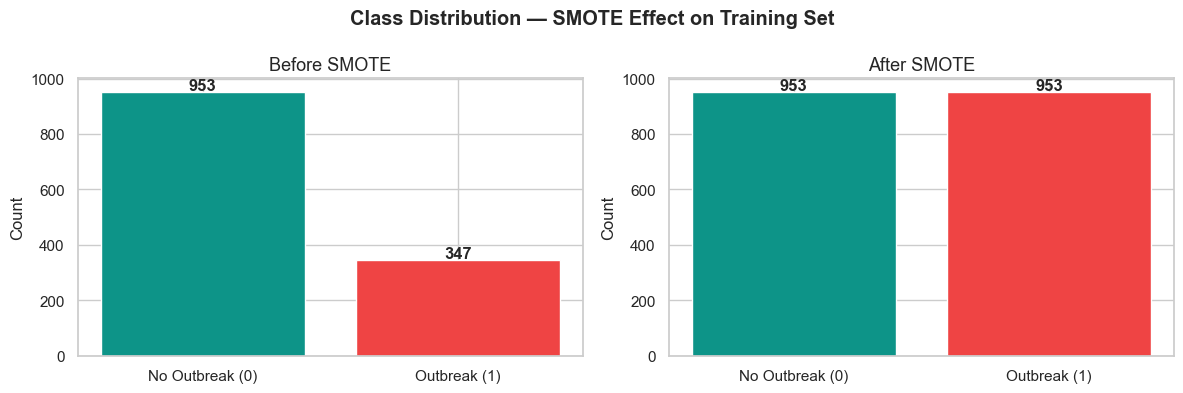

In [ ]:
# ── SMOTE on training set only ────────────────────────────────────────────────
# We apply SMOTE to the SCALED training data (for LogReg use)
# For XGBoost, apply to unscaled X_train

print("Before SMOTE:")
print(f"  Train class 0 : {(y_train == 0).sum():,}")
print(f"  Train class 1 : {(y_train == 1).sum():,}")
print(f"  Imbalance ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")
print()

smote = SMOTE(
    random_state=42,
    k_neighbors=5,      # Number of nearest neighbors to consider
    sampling_strategy='minority'  # Oversample minority class to match majority
)

# Apply to scaled data (for Logistic Regression)
X_train_scaled_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Apply to unscaled data (for XGBoost)
X_train_sm, _ = smote.fit_resample(X_train, y_train)

print("After SMOTE (scaled — for Logistic Regression):")
print(f"  Train class 0 : {(y_train_sm == 0).sum():,}")
print(f"  Train class 1 : {(y_train_sm == 1).sum():,}")
print(f"  Total rows    : {len(y_train_sm):,}")
print()

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_data, title in zip(axes, [y_train, y_train_sm], ['Before SMOTE', 'After SMOTE']):
    counts = y_data.value_counts()
    ax.bar(['No Outbreak (0)', 'Outbreak (1)'], counts.values, 
           color=['#0D9488', '#EF4444'], edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution — SMOTE Effect on Training Set', fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 12 — Export Final Datasets

We save everything needed for model training:
- `feature_store.csv` — full engineered dataset (all splits combined, with Year/Country)
- `X_train.csv`, `X_val.csv`, `X_test.csv` — unscaled splits for XGBoost
- `X_train_scaled.csv`, `X_val_scaled.csv`, `X_test_scaled.csv` — scaled splits for LogReg
- `X_train_smote.csv`, `y_train_smote.csv` — SMOTE-augmented training data
- `scaler_params.csv` — scaler mean/std for reproducibility

These files feed directly into your **MLflow experiment tracking** notebook.


In [ ]:
# ── Export full feature store ─────────────────────────────────────────────────
import os
os.makedirs('feature_store', exist_ok=True)

# Full engineered dataset (useful for EDA and MLflow logging)
df_model.to_csv('feature_store/feature_store.csv', index=False)

# Unscaled splits (XGBoost)
X_train.to_csv('feature_store/X_train.csv', index=False)
X_val.to_csv('feature_store/X_val.csv', index=False)
X_test.to_csv('feature_store/X_test.csv', index=False)
y_train.to_csv('feature_store/y_train.csv', index=False)
y_val.to_csv('feature_store/y_val.csv', index=False)
y_test.to_csv('feature_store/y_test.csv', index=False)

# Scaled splits (Logistic Regression)
X_train_scaled.to_csv('feature_store/X_train_scaled.csv', index=False)
X_val_scaled.to_csv('feature_store/X_val_scaled.csv', index=False)
X_test_scaled.to_csv('feature_store/X_test_scaled.csv', index=False)

# SMOTE-augmented training
pd.DataFrame(X_train_scaled_sm, columns=FEATURE_COLS).to_csv('feature_store/X_train_smote.csv', index=False)
pd.Series(y_train_sm, name='Outbreak_Label').to_csv('feature_store/y_train_smote.csv', index=False)

# Scaler parameters (needed to reproduce scaling at inference time)
scaler_params = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean': scaler.mean_,
    'std': scaler.scale_
})
scaler_params.to_csv('feature_store/scaler_params.csv', index=False)

print("✅ All files exported to feature_store/")
print()
for f in sorted(os.listdir('feature_store')):
    size = os.path.getsize(f'feature_store/{f}')
    print(f"   {f:35s} {size/1024:.1f} KB")


✅ All files exported to feature_store/

   X_test.csv                          69.3 KB
   X_test_scaled.csv                   100.6 KB
   X_train.csv                         383.7 KB
   X_train_scaled.csv                  551.3 KB
   X_train_smote.csv                   806.5 KB
   X_val.csv                           73.8 KB
   X_val_scaled.csv                    107.0 KB
   feature_store.csv                   556.0 KB
   scaler_params.csv                   1.2 KB
   y_test.csv                          0.7 KB
   y_train.csv                         3.8 KB
   y_train_smote.csv                   5.6 KB
   y_val.csv                           0.8 KB


---
## ✅ Feature Engineering Complete — Summary

### What was built

| Category | Features Created | Count |
|----------|----------------|-------|
| Lag features | Malaria_Lag1/2/3, Temp_Lag1, Precip_Lag1, GDP_Lag1 | 6 |
| Rolling averages | Malaria_Roll3, Temp_Roll3, Precip_Roll3 | 3 |
| Change rates | Malaria_YoY_Change | 1 |
| Climate interactions | Temp_Precip_Interaction, Temp_Squared | 2 |
| Risk indices | Climate_Risk_Index, Vulnerability_Index | 2 |
| Log transforms | Log_GDP, Log_Malaria_Incidence | 2 |
| **Total new features** | | **16** |
| **Total feature set** | Original (6) + Engineered (16) | **22** |

### What each output feeds into

```
feature_store/
├── X_train.csv + y_train.csv          → XGBoost training
├── X_train_scaled.csv + y_train.csv   → Logistic Regression training
├── X_train_smote.csv + y_train_smote.csv → Imbalance-corrected training
├── X_val / X_test (scaled & unscaled) → Evaluation
└── scaler_params.csv                  → FastAPI inference (reproduce scaling)
```

### Next steps
1. **Model Training notebook** — Train LogReg + XGBoost, log to MLflow
2. **MLflow** — Compare experiments, register best model
3. **FastAPI** — Load registered model + scaler_params for /predict endpoint
